In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

src = Path.home() /'5github' /'harmonic_polynomial'/'src'
sys.path.append(str(src))

from harmonic_polynomial import build_pi_basis_matrix, compute_glm_coefficients

data_dir = Path.home() / "Desktop" / "nedm-data"/ "B0" / "mapper_df.csv"
b0_df = pd.read_csv(data_dir)
b0_df.columns = ['x','y', 'z', 'bx', 'by', 'bz']

In [2]:
glm_df = compute_glm_coefficients(df= b0_df)

In [3]:
def reconstruct_fields(df, glm_df):
    """
    Reconstruct the magnetic field from the best fitted harmonic coefficients.

    Returns :  DataFrame containing x, y, z and reconstructed bx, by, bz.
    """

    x, y, z = [df[col] for col in ("x", "y", "z")]

    _, basis_matrix = build_pi_basis_matrix(df)

    glm_coeff = glm_df["g_lm"].to_numpy()

    basis_bx, basis_by, basis_bz = np.split(basis_matrix, 3)

    pred_bx = basis_bx @ glm_coeff
    pred_by = basis_by @ glm_coeff
    pred_bz = basis_bz @ glm_coeff

    reconstructed_df = pd.DataFrame({
        "x": x,
        "y": y,
        "z": z,
        "bx": pred_bx,
        "by": pred_by,
    "bz": pred_bz,})

    return reconstructed_df


reconstructed_df = reconstruct_fields(df=b0_df, glm_df=glm_df)

In [4]:
reconstructed_df.head()

,x,y,z,bx,by,bz
0,-0.144338,-1.767500e-17,-0.15,-0.090818,0.445392,1021.420543
1,-0.135633,-4.936636e-02,-0.15,-0.077988,0.453170,1021.427736
2,-0.142145,-2.506396e-02,-0.15,-0.085810,0.449554,1021.424811
3,-0.125000,-7.216878e-02,-0.15,-0.067570,0.456207,1021.429145
4,-0.110569,-9.277840e-02,-0.15,-0.054842,0.458617,1021.428960


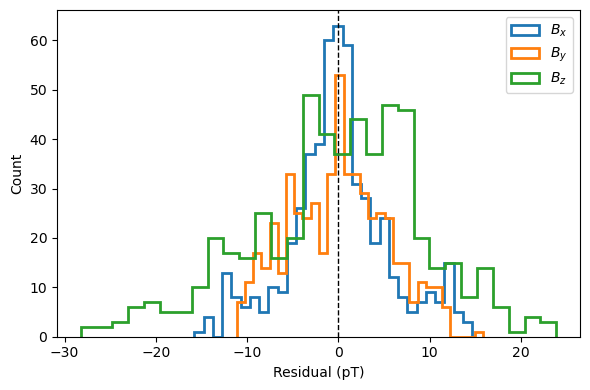

In [5]:
def plot_residual_hist(df1, df2, bins=30):

    plt.figure(figsize=(6, 4))

    for comp in ("bx", "by", "bz"):
        plt.hist( (df1[comp] - df2[comp]) * 1000,
            bins=bins, histtype="step",
            linewidth=2, label=rf"$B_{{{comp[-1]}}}$")

    plt.axvline(0, color="k", ls="--", lw=1)
    plt.xlabel("Residual (pT)")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_residual_hist(b0_df, reconstructed_df)

In [1]:
from pathlib import Path

In [7]:
Path.cwd()

PosixPath('/Users/prakashadhikari/5github/harmonic_polynomial/notebooks')